In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

In [ ]:
# 1️) Unzip Dataset

zip_path = "D:/Projects/Project-5-Multiclass Fish Image Classification/Dataset.zip"   # <-- change this if your zip file name is different
extract_path = "fish_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Extracted {zip_path} to {extract_path}")
else:
    print(f"📂 Dataset already extracted: {extract_path}")

📂 Dataset already extracted: fish_dataset


In [ ]:
# 2️) Correct Folder Paths

train_dir = "fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train"
val_dir   = "fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val"
test_dir  = "fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test"

# Verify paths
print("Train exists:", os.path.exists(train_dir))
print("Val exists:", os.path.exists(val_dir))
print("Test exists:", os.path.exists(test_dir))
print("Train classes:", os.listdir(train_dir)[:5])

Train exists: True
Val exists: True
Test exists: True
Train classes: ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel']


In [ ]:
# 3️) Data Preprocessing & Augmentation

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

num_classes = len(train_gen.class_indices)
class_labels = list(train_gen.class_indices.keys())

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


In [ ]:
# 4️) Define CNN Model (from scratch)

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# 5️) Pretrained Models Setup
pretrained_models = {
    "VGG16": VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "ResNet50": ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "MobileNet": MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "InceptionV3": InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "EfficientNetB0": EfficientNetB0(weights=None, include_top=False, input_shape=(224,224,3))
}

def build_finetune_model(base_model, num_classes):
    for layer in base_model.layers:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
# 6️) Train and Evaluate Models

models_to_train = {"CustomCNN": build_custom_cnn()}

for name, base in pretrained_models.items():
    models_to_train[name] = build_finetune_model(base, num_classes)

history_dict = {}
metrics_summary = []
best_accuracy = 0
best_model_name = None
best_model = None

for model_name, model in models_to_train.items():
    print(f"\n🔹 Training {model_name} model...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        verbose=1
    )
    history_dict[model_name] = history.history

    # Evaluate on test data
    test_loss, test_acc = model.evaluate(test_gen)
    metrics_summary.append([model_name, test_acc, test_loss])

    # Track best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_model_name = model_name
        best_model = model

# 7️) Save Best Model as .pkl

if best_model:
    with open("best_fish_model.pkl", "wb") as file:
        pickle.dump(best_model, file)
    print(f"\n✅ Best model saved: {best_model_name} with Accuracy = {best_accuracy:.4f}")

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🔹 Training CustomCNN model...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2649s 14s/step - accuracy: 0.3508 - loss: 1.8464 - val_accuracy: 0.5778 - val_loss: 1.3621
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2863s 15s/step - accuracy: 0.5144 - loss: 1.4259 - val_accuracy: 0.7005 - val_loss: 1.0470
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2773s 14s/step - accuracy: 0.6031 - loss: 1.1962 - val_accuracy: 0.7875 - val_loss: 0.8255
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2755s 14s/step - accuracy: 0.6659 - loss: 1.0187 - val_accuracy: 0.7555 - val_loss: 0.7468
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2140s 11s/step - accuracy: 0.6977 - loss: 0.9009 - val_accuracy: 0.8425 - val_loss: 0.5500
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1906s 10s/step - accuracy: 0.7253 - loss: 0.8202 - val_accuracy: 0.8590 - val_loss: 0.4857
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1947s 10s/step - accuracy: 0.7608 - loss: 0.7219 - val_accuracy: 0.8745 - val_loss: 0.4851
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2034s 10s/step - accuracy: 0.7827 - loss: 0

In [ ]:
#8️)Evaluation Metrics & Reports

test_gen.reset()
predictions = best_model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

100/100 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step

Classification Report:
                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       520
                animal fish bass       1.00      0.46      0.63        13
   fish sea_food black_sea_sprat       0.99      0.99      0.99       298
   fish sea_food gilt_head_bream       1.00      0.99      0.99       305
   fish sea_food hourse_mackerel       0.98      1.00      0.99       286
        fish sea_food red_mullet       1.00      0.97      0.98       291
     fish sea_food red_sea_bream       0.99      1.00      0.99       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.97      0.99      0.98       293
             fish sea_food trout       1.00      1.00      1.00       292

                        accuracy            

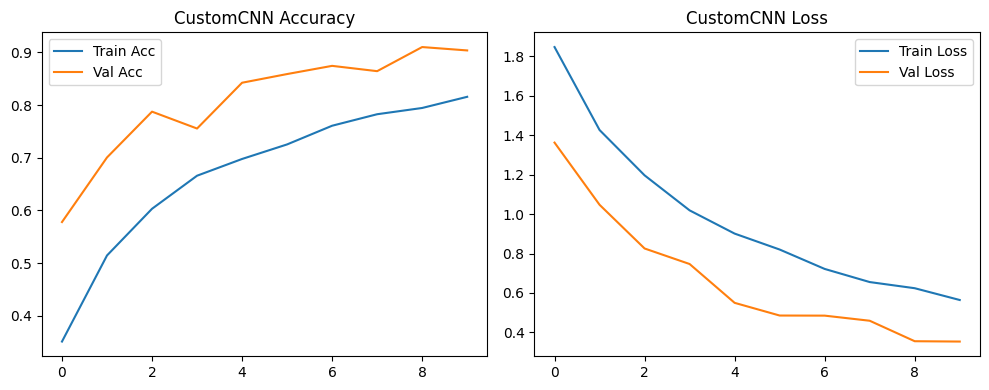

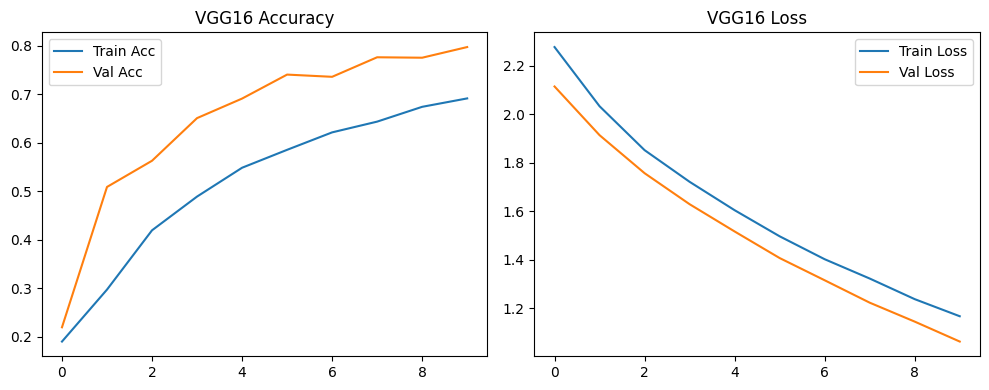

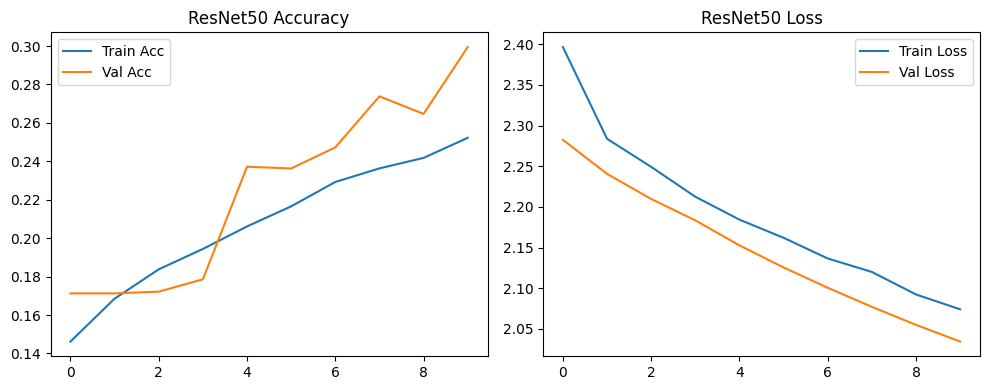

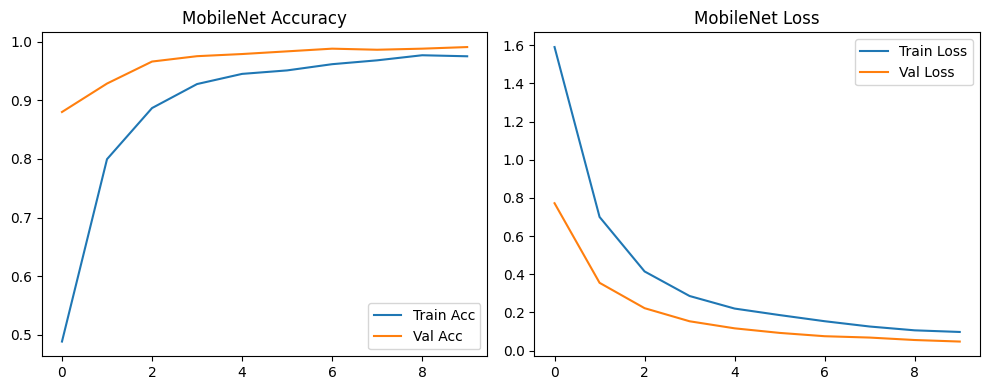

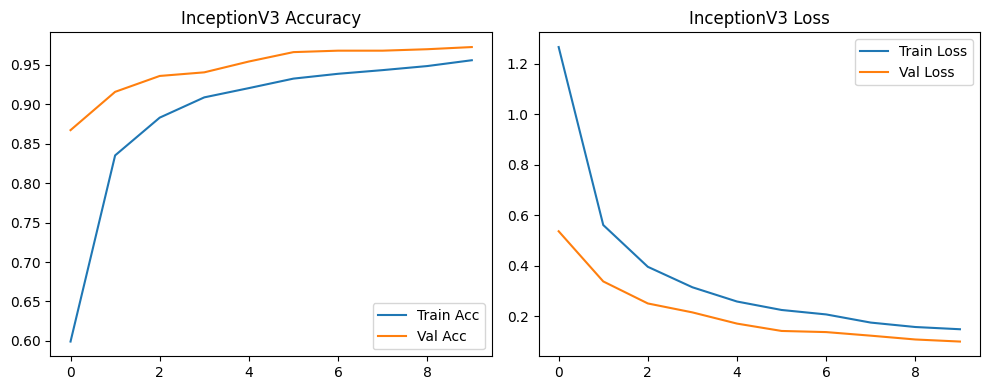

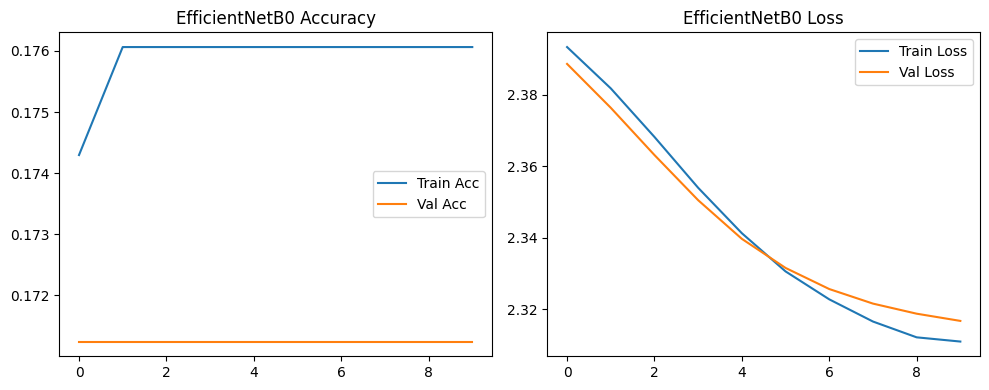

In [ ]:
# 9️) Visualization: Accuracy & Loss

for model_name, hist in history_dict.items():
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [10]:
#only for my understanding
import os

base_path = "fish_dataset"   # change this to your extracted folder name if different

for root, dirs, files in os.walk(base_path):
    print("📁", root)
    for d in dirs:
        print("  ├──", d)
    for f in files[:5]:  # show up to 5 files
        print("  ├──", f)
    print("-" * 50)


📁 fish_dataset
  ├── images.cv_jzk6llhf18tm3k0kyttxz
--------------------------------------------------
📁 fish_dataset\images.cv_jzk6llhf18tm3k0kyttxz
  ├── data
  ├── readme.txt
--------------------------------------------------
📁 fish_dataset\images.cv_jzk6llhf18tm3k0kyttxz\data
  ├── test
  ├── train
  ├── val
--------------------------------------------------
📁 fish_dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\test
  ├── animal fish
  ├── animal fish bass
  ├── fish sea_food black_sea_sprat
  ├── fish sea_food gilt_head_bream
  ├── fish sea_food hourse_mackerel
  ├── fish sea_food red_mullet
  ├── fish sea_food red_sea_bream
  ├── fish sea_food sea_bass
  ├── fish sea_food shrimp
  ├── fish sea_food striped_red_mullet
  ├── fish sea_food trout
--------------------------------------------------
📁 fish_dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\test\animal fish
  ├── 00ZR1T3Q2G5Z.jpg
  ├── 0982EFXJOXH9.jpg
  ├── 0AKFISD3OVLE.jpg
  ├── 0AUE3U3PPXVL.jpg
  ├── 0BJD9F3STSQ7.jpg
-------